In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [80]:
df = pd.DataFrame({
    "id":[101,102,103,104,105,106],
    "Age":[19,20,21,22,25,26],
    "maths":[20,40,50,100,120,110],
    "science":[12,18,20,30,35,40]
})

In [20]:
import warnings
warnings.filterwarnings('ignore')
kmean = KMeans(n_clusters=2,init='k-means++',random_state=42)
df['cluster'] = kmean.fit_predict(df[['maths','science']])

In [21]:
df

,id,Age,maths,science,cluster
0,101,19,20,12,0
1,102,20,40,18,0
2,103,21,50,20,0
3,104,22,100,30,1
4,105,25,120,35,1
5,106,26,110,40,1


In [25]:
kmean.cluster_centers_

array([[ 36.66666667,  16.66666667],
       [110.        ,  35.        ]])

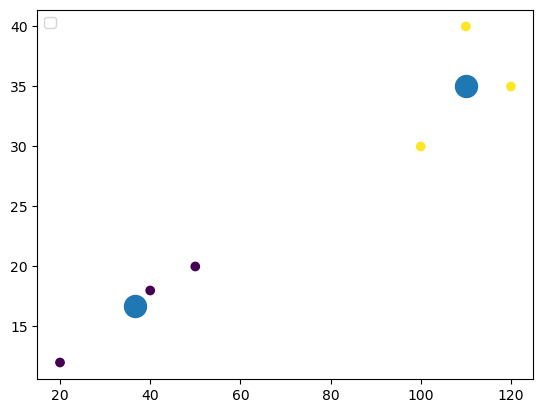

In [44]:
plt.scatter(df['maths'],df['science'],c=df['cluster'])
# sns.scatterplot(data=df,x='maths',y='science',hue='cluster')
plt.scatter(kmean.cluster_centers_[:,0],kmean.cluster_centers_[:,1],s=250)
plt.legend(loc='upper left')
plt.show()

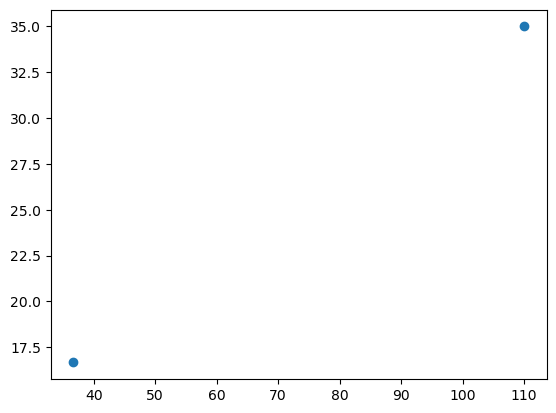

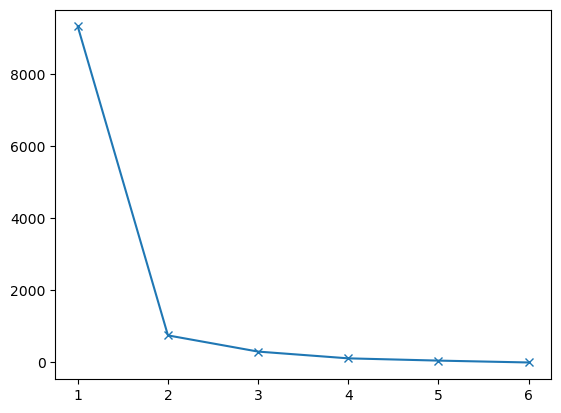

In [81]:
X = df[['maths','science']]
wcss = [ ]
for k in range(1,len(X)+1):
    km = KMeans(n_clusters=k,init='k-means++',random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,len(x)+1),wcss,marker='x')
plt.show()

In [67]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [69]:
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

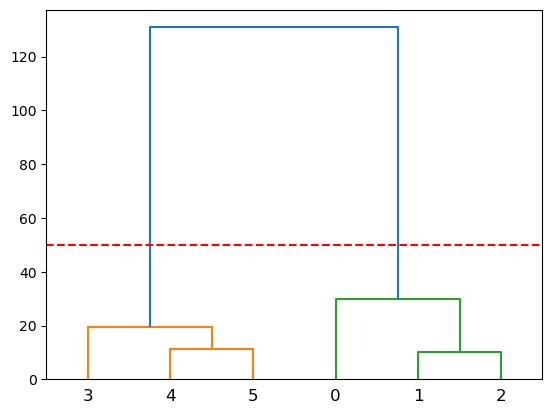

In [89]:
# create linkage :
X = df[['maths','science']]
linked = linkage(X,method='ward')
dendrogram(linked)
plt.axhline(y=50,linestyle='--',c='r')
plt.show()

In [83]:
hc = AgglomerativeClustering(n_clusters=3,linkage='ward')
label=hc.fit_predict(X)
print(label)

[2 1 1 0 0 0]
